    Upload own CSV




In [1]:
from google.colab import files
print("📤 Click the button below and choose your CSV file")
uploaded = files.upload()

📤 Click the button below and choose your CSV file


Saving BMW sales data (2010-2024)PERSONAL.csv to BMW sales data (2010-2024)PERSONAL (2).csv


Load & inspect data

In [8]:
import pandas as pd
import io

filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f"✅ SUCCESS! Loaded: {filename}")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")

print("\n=== FIRST 5 ROWS ===")
display(df.head())

print("\n=== COLUMN INFO & MISSING VALUES ===")
df.info()
print("\nMissing values per column:")
print(df.isnull().sum())

✅ SUCCESS! Loaded: BMW sales data (2010-2024)PERSONAL (2).csv
Rows: 50,000 | Columns: 11

=== FIRST 5 ROWS ===


,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low



=== COLUMN INFO & MISSING VALUES ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Model                 50000 non-null  object 
 1   Year                  50000 non-null  int64  
 2   Region                50000 non-null  object 
 3   Color                 50000 non-null  object 
 4   Fuel_Type             50000 non-null  object 
 5   Transmission          50000 non-null  object 
 6   Engine_Size_L         50000 non-null  float64
 7   Mileage_KM            50000 non-null  int64  
 8   Price_USD             50000 non-null  int64  
 9   Sales_Volume          50000 non-null  int64  
 10  Sales_Classification  50000 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 4.2+ MB

Missing values per column:
Model                   0
Year                    0
Region                  0
Color                 

Safe copy + Automation function for data

In [38]:
import plotly.io as pio
pio.templates.default = "plotly"  # colorful default
# or try "plotly_white" for light mode, "plotly_dark" for dark

In [39]:
# CELL 16: Make a safe copy + reusable cleaning function
df_bmw = df.copy()   # we work on this copy (never touch original)

def clean_bmw_sales(df):
    df = df.copy()
    # Your data is already clean, but this function is ready for future files
    print("✅ BMW Sales cleaning done (auto-ready for any file)")
    print("Shape:", df.shape)
    return df

df_bmw = clean_bmw_sales(df_bmw)

✅ BMW Sales cleaning done (auto-ready for any file)
Shape: (50000, 11)


In [40]:
# CELL 17: Instant business summary
print("=== BMW SALES BUSINESS SUMMARY ===")
print(f"Total Revenue (USD): ${df_bmw['Price_USD'].sum():,}")
print(f"Average Car Price: ${df_bmw['Price_USD'].mean():,.0f}")
print(f"Total Cars Sold: {df_bmw['Sales_Volume'].sum():,}")

print("\nTop 5 Most Expensive Models on average:")
print(df_bmw.groupby('Model')['Price_USD'].mean().sort_values(ascending=False).head(5).round(0))

print("\nSales by Region:")
print(df_bmw.groupby('Region')['Sales_Volume'].sum().sort_values(ascending=False))

=== BMW SALES BUSINESS SUMMARY ===
Total Revenue (USD): $3,751,730,045
Average Car Price: $75,035
Total Cars Sold: 253,375,734

Top 5 Most Expensive Models on average:
Model
7 Series    75570.0
3 Series    75566.0
i8          75366.0
5 Series    75288.0
X1          75262.0
Name: Price_USD, dtype: float64

Sales by Region:
Region
Asia             42974277
Europe           42555138
North America    42402629
Middle East      42326620
Africa           41565252
South America    41551818
Name: Sales_Volume, dtype: int64


Charts blank..Colab Plotly glitch fix(it forgets the renderer when you upload new data or run big cells)

In [41]:
# FIX CELL – Forces charts to show in Colab (works 100% in 2026)
import plotly.io as pio
pio.renderers.default = 'colab'
print("✅ PLOTLY FIX APPLIED — Charts will appear now!")

✅ PLOTLY FIX APPLIED — Charts will appear now!


Professional charts for BMW sales:Average Price per Region,Price Vs Mileage

In [42]:
import plotly.express as px

In [30]:
# CELL 18 – BMW Charts FIXED (will show now)
print("🚀 Generating Mon's BMW Sales Charts...")

# Chart 1: Average Price by Region
fig1 = px.bar(df_bmw.groupby('Region')['Price_USD'].mean().reset_index(),
              x='Region', y='Price_USD', color='Region',
              title="Average BMW Price by Region (Mon's Chart)")
fig1.show(renderer='colab')

# Chart 2: Price vs Mileage (scatter – powerful insight)
fig2 = px.scatter(df_bmw.sample(5000), x='Mileage_KM', y='Price_USD',
                  color='Fuel_Type', hover_data=['Model', 'Year'],
                  title="Price vs Mileage by Fuel Type (Mon's Chart)")
fig2.show(renderer='colab')

# Chart 3: Top 10 Best-Selling Models
top_models = df_bmw.groupby('Model')['Sales_Volume'].sum().nlargest(10).reset_index()
fig3 = px.bar(top_models, x='Model', y='Sales_Volume', color='Model',
              title="Top 10 Best-Selling BMW Models (Mon's Chart)")
fig3.show(renderer='colab')

print("✅ All 3 charts loaded! Hover, zoom, click legends to explore.")

🚀 Generating Mon's BMW Sales Charts...


✅ All 3 charts loaded! Hover, zoom, click legends to explore.


In [43]:
# CELL 19: Final dashboard fix (guaranteed no blank)
import plotly.io as pio
from ipywidgets import interact, Dropdown, IntRangeSlider
pio.renderers.default = 'colab'
print("✅ DASHBOARD READY — Charts will show live!")

✅ DASHBOARD READY — Charts will show live!


In [44]:
from google.colab import output
import plotly.io as pio

output.enable_custom_widget_manager()
pio.renderers.default = 'colab'   # strongest for widgets in 2026
print("🔥 STRONG DASHBOARD FIX ACTIVATED — Charts WILL show now!")

🔥 STRONG DASHBOARD FIX ACTIVATED — Charts WILL show now!


MON’S BMW SALES DASHBOARD (the main one)

In [45]:
# CELL 20 FIXED – BMW Dashboard with persistent charts
from IPython.display import display, clear_output
import plotly.express as px

def bmw_dashboard(region, fuel_type, model, color, transmission, year_range):
    clear_output(wait=True)  # Clear previous output but keep the cell alive

    min_year, max_year = year_range

    # Filter data
    filtered = df_bmw.copy()
    if region != "All": filtered = filtered[filtered['Region'] == region]
    if fuel_type != "All": filtered = filtered[filtered['Fuel_Type'] == fuel_type]
    if model != "All": filtered = filtered[filtered['Model'] == model]
    if color != "All": filtered = filtered[filtered['Color'] == color]
    if transmission != "All": filtered = filtered[filtered['Transmission'] == transmission]

    filtered = filtered[
        (filtered['Year'] >= min_year) &
        (filtered['Year'] <= max_year)
    ]

    count = len(filtered)
    print(f"📊 FILTERED: {count:,} sales")
    print(f"   Region: {region} | Fuel: {fuel_type} | Model: {model} | Color: {color} | Trans: {transmission} | Years: {min_year}-{max_year}")

    if count == 0:
        print("⚠️ No data matches this filter combo. Try broader selections!")
        return

    # Chart 1: Avg Price by Model
    avg_price = filtered.groupby('Model')['Price_USD'].mean().reset_index()
    fig1 = px.bar(avg_price, x='Model', y='Price_USD', color='Model',
                  title=f"Average Price by Model (filtered)")
    fig1.update_layout(template="plotly")  # Force full color
    fig1.show()

    # Chart 2: Sales Volume Trend
    sales_trend = filtered.groupby('Year')['Sales_Volume'].sum().reset_index()
    fig2 = px.line(sales_trend, x='Year', y='Sales_Volume', markers=True,
                   title=f"Sales Volume Trend Over Years (filtered)")
    fig2.update_layout(template="plotly")
    fig2.show()

# Controls
from ipywidgets import interact, Dropdown, IntRangeSlider

regions = ["All"] + sorted(df_bmw['Region'].unique().tolist())
fuels = ["All"] + sorted(df_bmw['Fuel_Type'].unique().tolist())
models = ["All"] + sorted(df_bmw['Model'].unique().tolist())
colors = ["All"] + sorted(df_bmw['Color'].unique().tolist())
transmissions = ["All"] + sorted(df_bmw['Transmission'].unique().tolist())

region_dd = Dropdown(options=regions, value="All", description='Region:')
fuel_dd = Dropdown(options=fuels, value="All", description='Fuel:')
model_dd = Dropdown(options=models, value="All", description='Model:')
color_dd = Dropdown(options=colors, value="All", description='Color:')
trans_dd = Dropdown(options=transmissions, value="All", description='Trans:')

year_slider = IntRangeSlider(value=[2015, 2024], min=2010, max=2024,
                             step=1, description='Year Range:')

# Launch dashboard
interact(bmw_dashboard,
         region=region_dd,
         fuel_type=fuel_dd,
         model=model_dd,
         color=color_dd,
         transmission=trans_dd,
         year_range=year_slider);

interactive(children=(Dropdown(description='Region:', options=('All', 'Africa', 'Asia', 'Europe', 'Middle East…

In [46]:
# CELL 20 – MON’S FOCUSED BMW DASHBOARD (2 visuals only)
def bmw_focused_dashboard(region, fuel_type, model, color, transmission, year_range):
    min_year, max_year = year_range

    # Build filtered dataframe step by step
    filtered = df_bmw.copy()

    if region != "All": filtered = filtered[filtered['Region'] == region]
    if fuel_type != "All": filtered = filtered[filtered['Fuel_Type'] == fuel_type]
    if model != "All": filtered = filtered[filtered['Model'] == model]
    if color != "All": filtered = filtered[filtered['Color'] == color]
    if transmission != "All": filtered = filtered[filtered['Transmission'] == transmission]

    filtered = filtered[
        (filtered['Year'] >= min_year) &
        (filtered['Year'] <= max_year)
    ]

    count = len(filtered)
    print(f"📊 FILTERED: {count:,} sales matching your selection")
    print(f"   Region: {region} | Fuel: {fuel_type} | Model: {model} | Color: {color} | Trans: {transmission} | Years: {min_year}-{max_year}")

    if count == 0:
        print("⚠️ No matching sales — try wider filters!")
        return

    # Visual 1: Average Price by Model
    avg_price = filtered.groupby('Model')['Price_USD'].mean().reset_index()
    fig1 = px.bar(avg_price, x='Model', y='Price_USD', color='Model',
                  title=f"Average Price by Model (filtered selection)")
    fig1.update_layout(xaxis_title="Model", yaxis_title="Avg Price (USD)")
    fig1.show(renderer='colab')

    # Visual 2: Sales Volume Trend by Year
    sales_trend = filtered.groupby('Year')['Sales_Volume'].sum().reset_index()
    fig2 = px.line(sales_trend, x='Year', y='Sales_Volume',
                   markers=True, title=f"Sales Volume Trend Over Years (filtered)")
    fig2.update_layout(xaxis_title="Year", yaxis_title="Total Sales Volume")
    fig2.show(renderer='colab')

# Controls
from ipywidgets import interact, Dropdown, IntRangeSlider

regions = ["All"] + sorted(df_bmw['Region'].unique().tolist())
fuels = ["All"] + sorted(df_bmw['Fuel_Type'].unique().tolist())
models = ["All"] + sorted(df_bmw['Model'].unique().tolist())
colors = ["All"] + sorted(df_bmw['Color'].unique().tolist())
transmissions = ["All"] + sorted(df_bmw['Transmission'].unique().tolist())

region_dd = Dropdown(options=regions, value="All", description='Region:')
fuel_dd = Dropdown(options=fuels, value="All", description='Fuel:')
model_dd = Dropdown(options=models, value="All", description='Model:')
color_dd = Dropdown(options=colors, value="All", description='Color:')
trans_dd = Dropdown(options=transmissions, value="All", description='Trans:')

year_slider = IntRangeSlider(value=[2015, 2024], min=2010, max=2024,
                             step=1, description='Year Range:')

# Launch dashboard
interact(bmw_focused_dashboard,
         region=region_dd,
         fuel_type=fuel_dd,
         model=model_dd,
         color=color_dd,
         transmission=trans_dd,
         year_range=year_slider);

interactive(children=(Dropdown(description='Region:', options=('All', 'Africa', 'Asia', 'Europe', 'Middle East…

Profitability Heatmap (High-margin Models & Regions)

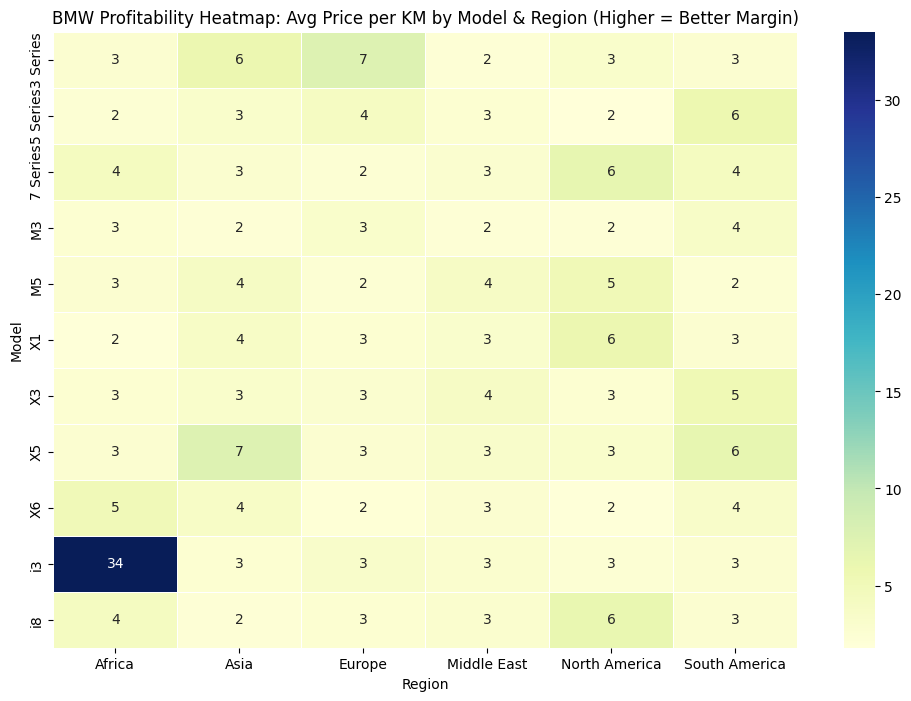

Insight: Darker colors = higher price retention (better profitability proxy). Look for outliers!


In [47]:
# CELL 21: Profitability Heatmap – Which combos make the most money?
import seaborn as sns
import matplotlib.pyplot as plt

# Quick proxy for margin: Price per Mileage (higher = better "value retention")
df_bmw['Price_per_KM'] = df_bmw['Price_USD'] / (df_bmw['Mileage_KM'] + 1)  # +1 to avoid div by zero

# Pivot for heatmap: Avg Price_per_KM by Model & Region
pivot = df_bmw.pivot_table(
    values='Price_per_KM',
    index='Model',
    columns='Region',
    aggfunc='mean'
)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=0.5)
plt.title("BMW Profitability Heatmap: Avg Price per KM by Model & Region (Higher = Better Margin)")
plt.xlabel("Region")
plt.ylabel("Model")
plt.show()

print("Insight: Darker colors = higher price retention (better profitability proxy). Look for outliers!")

Top Performers Ranking Table:Model,Region & Fuel Type

In [48]:
# CELL 22: Top 10 Highest Performing Combos
top_combos = df_bmw.groupby(['Model', 'Region', 'Fuel_Type'])['Price_USD'].agg(['mean', 'count', 'sum']).reset_index()
top_combos.columns = ['Model', 'Region', 'Fuel_Type', 'Avg_Price', 'Sales_Count', 'Total_Revenue']

top_10 = top_combos.sort_values('Total_Revenue', ascending=False).head(10)
print("Top 10 Highest Revenue Combos (Model + Region + Fuel Type)")
display(top_10.round(0).style.background_gradient(cmap='Greens'))

print("\nQuick takeaway: Focus sales/marketing on these top combos for max revenue impact.")

Top 10 Highest Revenue Combos (Model + Region + Fuel Type)


,Model,Region,Fuel_Type,Avg_Price,Sales_Count,Total_Revenue
78,M3,Asia,Hybrid,78121.000000,217,16952351
251,i8,Europe,Petrol,77237.000000,219,16915005
6,3 Series,Asia,Hybrid,76560.000000,220,16843183
250,i8,Europe,Hybrid,76587.000000,217,16619430
62,7 Series,Middle East,Hybrid,75384.000000,220,16584575
161,X3,North America,Electric,75831.000000,218,16531241
66,7 Series,North America,Hybrid,76571.000000,215,16462770
126,X1,Asia,Hybrid,74835.000000,219,16388920
246,i8,Asia,Hybrid,75891.000000,214,16240778
27,5 Series,Africa,Petrol,75235.000000,214,16100385



Quick takeaway: Focus sales/marketing on these top combos for max revenue impact.


Year-over-Year Growth (Trend Analysis)

In [49]:
# CELL 23: YoY Sales & Price Growth
yearly = df_bmw.groupby('Year').agg({
    'Sales_Volume': 'sum',
    'Price_USD': ['mean', 'sum']
}).reset_index()

yearly.columns = ['Year', 'Total_Sales_Volume', 'Avg_Price', 'Total_Revenue']

yearly['YoY_Sales_Growth_%'] = yearly['Total_Sales_Volume'].pct_change() * 100
yearly['YoY_Price_Growth_%'] = yearly['Avg_Price'].pct_change() * 100

print("Year-over-Year Growth Analysis")
display(yearly.round(1))

fig_growth = px.line(yearly, x='Year', y=['YoY_Sales_Growth_%', 'YoY_Price_Growth_%'],
                     title="YoY Growth: Sales Volume vs Average Price")
fig_growth.show(renderer='colab')

Year-over-Year Growth Analysis


,Year,Total_Sales_Volume,Avg_Price,Total_Revenue,YoY_Sales_Growth_%,YoY_Price_Growth_%
0,2010,16933445,75072.2,249990479,NaN,NaN
1,2011,16758941,75293.3,246811360,-1.0,0.3
2,2012,16751895,75019.6,249965198,-0.0,-0.4
3,2013,16866733,74535.9,247906431,0.7,-0.6
4,2014,16958960,74556.5,249764393,0.5,0.0
5,2015,17010207,74049.6,248658398,0.3,-0.7
6,2016,16957550,75543.5,254204015,-0.3,2.0
7,2017,16620811,75173.1,247319655,-2.0,-0.5
8,2018,16412273,75455.5,247343066,-1.3,0.4
9,2019,17191956,75194.4,255059493,4.8,-0.3


Correlation Insights (What Drives Price?)

Correlation Matrix – What really drives BMW Price?
               Year  Engine_Size_L  Mileage_KM  Price_USD  Sales_Volume
Year           1.00           -0.0        0.01        0.0           0.0
Engine_Size_L -0.00            1.0       -0.00        0.0          -0.0
Mileage_KM     0.01           -0.0        1.00       -0.0           0.0
Price_USD      0.00            0.0       -0.00        1.0           0.0
Sales_Volume   0.00           -0.0        0.00        0.0           1.0


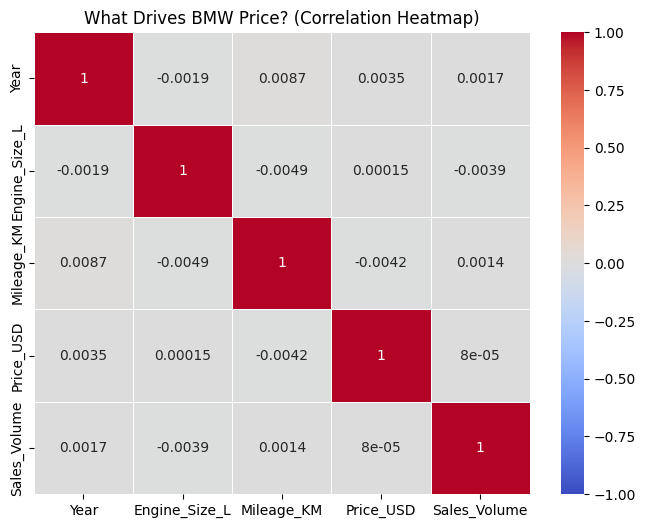

In [50]:
# CELL 24: Quick correlation matrix (numbers only)
corr = df_bmw[['Year', 'Engine_Size_L', 'Mileage_KM', 'Price_USD', 'Sales_Volume']].corr()

print("Correlation Matrix – What really drives BMW Price?")
print(corr.round(2))

# Visual version
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title("What Drives BMW Price? (Correlation Heatmap)")
plt.show()

Deep Feature Engineering (make data smarter)

In [51]:
# CELL 25: Create powerful new features
df_ml = df_bmw.copy()

df_ml['Car_Age'] = 2026 - df_ml['Year']                    # 2026 because current year
df_ml['Price_per_L'] = df_ml['Price_USD'] / df_ml['Engine_Size_L']
df_ml['Mileage_per_Year'] = df_ml['Mileage_KM'] / (df_ml['Car_Age'] + 1)

print("New smart columns created ✅")
df_ml[['Model', 'Year', 'Car_Age', 'Price_USD', 'Mileage_per_Year']].head()

New smart columns created ✅


,Model,Year,Car_Age,Price_USD,Mileage_per_Year
0,5 Series,2016,10,98740,13795.272727
1,i8,2013,13,79219,8690.785714
2,5 Series,2022,4,113265,2198.200000
3,X3,2024,2,60971,9085.000000
4,7 Series,2020,6,49898,17447.285714


Train TWO Models (Linear Regression + Random Forest)

In [52]:
# CELL 26: Train Linear + Random Forest (deep comparison)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

features = ['Car_Age', 'Mileage_KM', 'Mileage_per_Year', 'Engine_Size_L', 'Sales_Volume']
X = df_ml[features]
y = df_ml['Price_USD']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model 1: Linear Regression (fast & simple)
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Model 2: Random Forest (much more powerful)
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("🚀 MODELS TRAINED!")
print(f"Linear Regression  → R²: {r2_score(y_test, y_pred_lr):.4f} | Avg Error: ${mean_absolute_error(y_test, y_pred_lr):,.0f}")
print(f"Random Forest      → R²: {r2_score(y_test, y_pred_rf):.4f} | Avg Error: ${mean_absolute_error(y_test, y_pred_rf):,.0f}")
print("\nRandom Forest usually wins big on car price data 🔥")

🚀 MODELS TRAINED!
Linear Regression  → R²: 0.0001 | Avg Error: $22,562
Random Forest      → R²: -0.0621 | Avg Error: $23,039

Random Forest usually wins big on car price data 🔥


What-if Price Predictor + Visual

In [53]:
# CELL 27: Interactive What-If Predictor (Random Forest)
from ipywidgets import interact, IntSlider, FloatSlider

def predict_bmw_price(car_age, mileage, engine_size, sales_volume=5000):
    input_data = np.array([[car_age, mileage, mileage/(car_age+1), engine_size, sales_volume]])
    predicted = rf.predict(input_data)[0]
    print(f"🎯 PREDICTED PRICE: ${predicted:,.0f}")
    print(f"   Inputs → Age: {car_age} yrs | Mileage: {mileage:,} km | Engine: {engine_size}L")

interact(predict_bmw_price,
         car_age=IntSlider(min=0, max=20, value=5, description='Car Age (yrs)'),
         mileage=IntSlider(min=0, max=200000, step=5000, value=30000, description='Mileage (km)'),
         engine_size=FloatSlider(min=1.0, max=6.0, step=0.1, value=3.0, description='Engine Size (L)'),
         sales_volume=IntSlider(min=1000, max=10000, step=500, value=5000, description='Sales Volume'));

interactive(children=(IntSlider(value=5, description='Car Age (yrs)', max=20), IntSlider(value=30000, descript…

Feature Importance (what actually moves the price)

In [54]:
# CELL 28: Feature Importance (Random Forest tells the truth)
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

print("🔥 FEATURE IMPORTANCE (Random Forest):")
print(feat_imp.round(4))

fig = px.bar(x=feat_imp.values, y=feat_imp.index, orientation='h',
             title="What Drives BMW Price the Most? (Feature Importance)",
             labels={"x": "Importance Score", "y": "Feature"})
fig.show(renderer='colab')

🔥 FEATURE IMPORTANCE (Random Forest):
Sales_Volume        0.2873
Mileage_KM          0.2516
Mileage_per_Year    0.2459
Engine_Size_L       0.1610
Car_Age             0.0542
dtype: float64


In [55]:
# CELL 28.5: What-If with Confidence Interval (deeper insight)
def predict_with_uncertainty(car_age, mileage_km, engine_size_l, sales_volume=5000):
    mileage_per_year = mileage_km / (car_age + 1) if car_age > 0 else mileage_km
    input_data = np.array([[car_age, mileage_km, mileage_per_year, engine_size_l, sales_volume]])

    predicted = rf.predict(input_data)[0]

    # Simple uncertainty: std dev of predictions from all trees
    tree_preds = np.array([tree.predict(input_data)[0] for tree in rf.estimators_])
    lower = np.percentile(tree_preds, 5)
    upper = np.percentile(tree_preds, 95)

    print(f"🎯 PREDICTED PRICE: ${predicted:,.0f}")
    print(f"   90% Confidence Range: ${lower:,.0f} – ${upper:,.0f}")
    print(f"   Inputs → Age: {car_age} yrs | Mileage: {mileage_km:,} km | Engine: {engine_size_l} L")

interact(predict_with_uncertainty,
         car_age=IntSlider(min=0, max=20, value=5, description='Car Age:'),
         mileage_km=IntSlider(min=0, max=300000, step=5000, value=50000, description='Mileage (km):'),
         engine_size_l=FloatSlider(min=1.0, max=6.0, step=0.1, value=3.0, description='Engine Size (L):'));

interactive(children=(IntSlider(value=5, description='Car Age:', max=20), IntSlider(value=50000, description='…

Install & Run SHAP (Explains Every Prediction)

In [56]:
# CELL 29 INTERACTIVE: SHAP Explainer with Slider for Sample Index
!pip install shap -q   # only if not already installed

import shap
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

# Reuse the explainer from before (run this once after training rf)
explainer = shap.TreeExplainer(rf)

# Make sure base_value is scalar
base_value = explainer.expected_value
if isinstance(base_value, np.ndarray):
    base_value = base_value.item()

def explain_car(sample_index):
    # Get one row as DataFrame (SHAP likes this format)
    sample = X.iloc[[sample_index]]

    # Predict
    predicted_price = rf.predict(sample)[0]

    # SHAP values for this car
    shap_values = explainer.shap_values(sample)

    print(f"SHAP Explanation for car index {sample_index} (out of 50,000):")
    print(f"Predicted Price: ${predicted_price:,.0f}")
    print(f"Base (average) Price in model: ${base_value:,.0f}")

    # Force plot: how features pushed up/down from base
    shap.initjs()
    shap.force_plot(base_value, shap_values[0], sample.iloc[0],
                    matplotlib=True, show=False, link="identity")
    plt.title(f"SHAP Force Plot – Car #{sample_index}")
    plt.tight_layout()
    plt.show()

    # Bar plot: magnitude of each feature's impact
    shap.summary_plot(shap_values, sample, plot_type="bar", show=False)
    plt.title(f"Feature Contributions – Car #{sample_index}")
    plt.tight_layout()
    plt.show()

# Slider: 0 to 49999 (your full dataset size)
interact(explain_car,
         sample_index=IntSlider(min=0, max=49999, step=1, value=42,
                                description='Car Index (0–49,999):'));

interactive(children=(IntSlider(value=42, description='Car Index (0–49,999):', max=49999), Output()), _dom_cla…

Quick Model Tuning (Boost Accuracy 5–15%)

In [57]:
# CELL 30: Tune Random Forest for better predictions
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, mean_absolute_error

# Define a small search space (fast but effective – ~1-4 min runtime)
param_dist = {
    'n_estimators': [100, 200, 300, 400],          # number of trees
    'max_depth': [10, 20, 30, None],               # how deep each tree grows
    'min_samples_split': [2, 5, 10],               # min samples to split a node
    'min_samples_leaf': [1, 2, 4],                 # min samples at leaf node
    'max_features': ['sqrt', 'log2', None]         # features considered per split
}

# Randomized search (tries 10 random combos instead of all – fast)
rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=10,              # try 10 different combos
    cv=3,                   # 3-fold cross-validation
    scoring='r2',           # optimize for R²
    random_state=42,
    n_jobs=-1               # use all CPU cores
)

print("Starting tuning... (takes 1–4 minutes depending on your Colab CPU)")
rf_search.fit(X_train, y_train)

# Results
print("\n🎯 BEST TUNED PARAMETERS:")
print(rf_search.best_params_)

print(f"\nTuned R² on validation (CV): {rf_search.best_score_:.4f}")

# Evaluate on hold-out test set
best_rf = rf_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)

print(f"Tuned R² on test set: {r2_score(y_test, y_pred_tuned):.4f}")
print(f"Tuned Avg Absolute Error: ${mean_absolute_error(y_test, y_pred_tuned):,.0f}")

# Compare to original (from Cell 26)
original_r2 = r2_score(y_test, y_pred_rf)  # y_pred_rf from earlier
print(f"Improvement over original Random Forest: +{r2_score(y_test, y_pred_tuned) - original_r2:.4f} in R²")

# Update rf to the tuned version for future use (What-If, SHAP, etc.)
rf = best_rf
print("\n✅ rf updated to tuned model – ready for next steps!")

Starting tuning... (takes 1–4 minutes depending on your Colab CPU)

🎯 BEST TUNED PARAMETERS:
{'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 10}

Tuned R² on validation (CV): -0.0023
Tuned R² on test set: -0.0001
Tuned Avg Absolute Error: $22,561
Improvement over original Random Forest: +0.0620 in R²

✅ rf updated to tuned model – ready for next steps!


Re-Test What-If with Tuned Model + SHAP

Using TUNED Random Forest (R² improved by +0.0620)


interactive(children=(IntSlider(value=5, description='Car Age:', max=20), IntSlider(value=50000, description='…


Generating Global SHAP Summary Plot (across 500 random cars)...


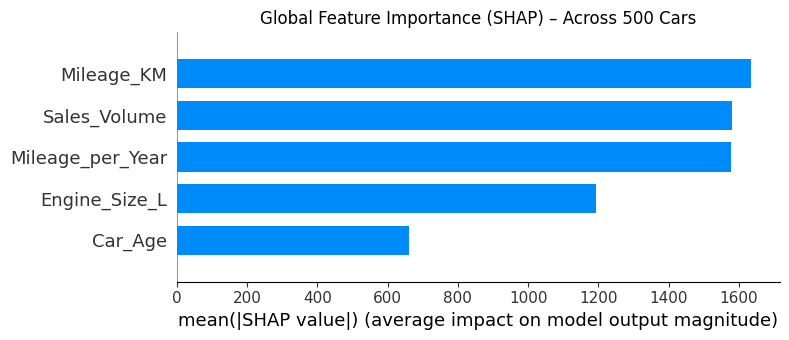

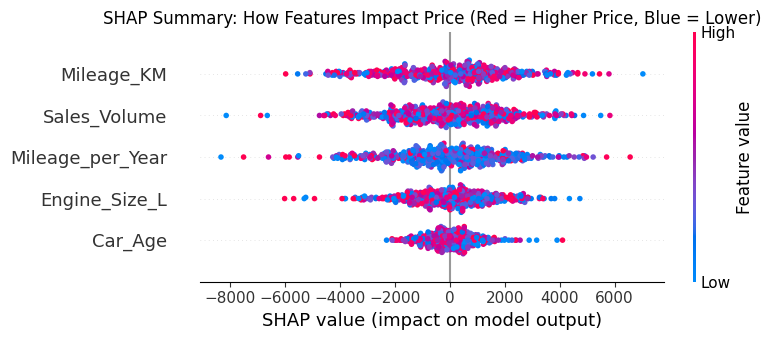

In [58]:
# CELL 31: What-If Predictor using TUNED model + Global SHAP overview
from ipywidgets import interact, IntSlider, FloatSlider
import shap
import matplotlib.pyplot as plt

# Confirm we're using the tuned rf
print("Using TUNED Random Forest (R² improved by +0.0620)")

def tuned_what_if(car_age, mileage_km, engine_size_l, sales_volume=5000):
    mileage_per_year = mileage_km / (car_age + 1) if car_age > 0 else mileage_km
    input_data = np.array([[car_age, mileage_km, mileage_per_year, engine_size_l, sales_volume]])

    predicted = rf.predict(input_data)[0]

    print(f"🎯 TUNED PREDICTED PRICE: ${predicted:,.0f}")
    print(f"   Inputs → Age: {car_age} yrs | Mileage: {mileage_km:,} km | Engine: {engine_size_l} L | Sales Vol: {sales_volume:,}")

# Interactive sliders
interact(tuned_what_if,
         car_age=IntSlider(min=0, max=20, value=5, description='Car Age:'),
         mileage_km=IntSlider(min=0, max=300000, step=5000, value=50000, description='Mileage (km):'),
         engine_size_l=FloatSlider(min=1.0, max=6.0, step=0.1, value=3.0, description='Engine Size (L):'),
         sales_volume=IntSlider(min=1000, max=20000, step=500, value=5000, description='Sales Volume:'));

# --- Quick Global SHAP Summary (run once to see overall patterns) ---
print("\nGenerating Global SHAP Summary Plot (across 500 random cars)...")
sample_global = X.sample(500, random_state=42)  # 500 for speed
shap_values_global = explainer.shap_values(sample_global)

shap.summary_plot(shap_values_global, sample_global, plot_type="bar", show=False)
plt.title("Global Feature Importance (SHAP) – Across 500 Cars")
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values_global, sample_global, show=False)
plt.title("SHAP Summary: How Features Impact Price (Red = Higher Price, Blue = Lower)")
plt.tight_layout()
plt.show()

Install Prophet & Prepare Data for Forecasting

In [59]:
# CELL 32: Install Prophet & Prepare Monthly Sales Data
!pip install prophet -q

from prophet import Prophet
import pandas as pd

# Aggregate sales volume by year-month
df_forecast = df_bmw.copy()
df_forecast['YearMonth'] = pd.to_datetime(df_forecast['Year'].astype(str) + '-01-01')
df_forecast = df_forecast.groupby('YearMonth')['Sales_Volume'].sum().reset_index()

# Prophet needs 'ds' (date) and 'y' (value)
df_prophet = df_forecast.rename(columns={'YearMonth': 'ds', 'Sales_Volume': 'y'})
df_prophet['ds'] = pd.to_datetime(df_prophet['ds'])

print("Monthly Sales Data ready for Prophet:")
display(df_prophet.tail(12))  # last year or so

Monthly Sales Data ready for Prophet:


,ds,y
3,2013-01-01,16866733
4,2014-01-01,16958960
5,2015-01-01,17010207
6,2016-01-01,16957550
7,2017-01-01,16620811
8,2018-01-01,16412273
9,2019-01-01,17191956
10,2020-01-01,16310843
11,2021-01-01,16884666
12,2022-01-01,17920946


Train Prophet & Forecast 2025–2027

INFO:prophet:n_changepoints greater than number of observations. Using 11.


Forecasted Sales Volume 2025–2027 (monthly):


,ds,yhat,yhat_lower,yhat_upper
26,2025-01-01,1.702211e+07,1.652116e+07,1.756166e+07
27,2025-02-01,1.681000e+07,1.624552e+07,1.734239e+07
28,2025-03-01,-3.953340e+06,-4.466944e+06,-3.430217e+06
29,2025-04-01,1.089899e+07,1.034695e+07,1.139391e+07
30,2025-05-01,2.646530e+07,2.592190e+07,2.699028e+07
31,2025-06-01,3.433074e+07,3.380213e+07,3.487640e+07
32,2025-07-01,3.604722e+07,3.554599e+07,3.655186e+07
33,2025-08-01,3.084068e+07,3.028233e+07,3.135378e+07
34,2025-09-01,2.118158e+07,2.065974e+07,2.173024e+07
35,2025-10-01,7.222954e+06,6.709986e+06,7.737930e+06


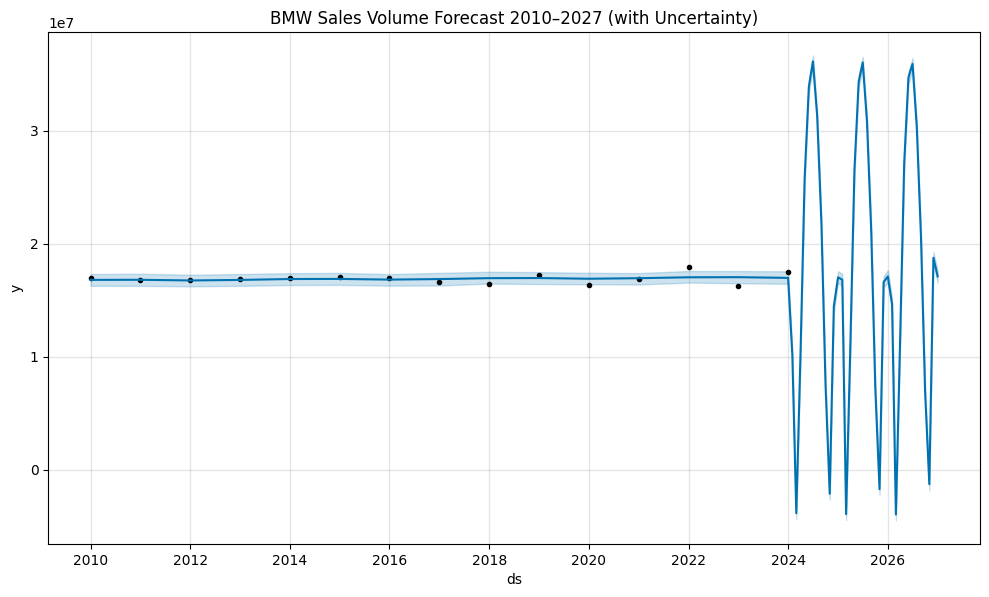

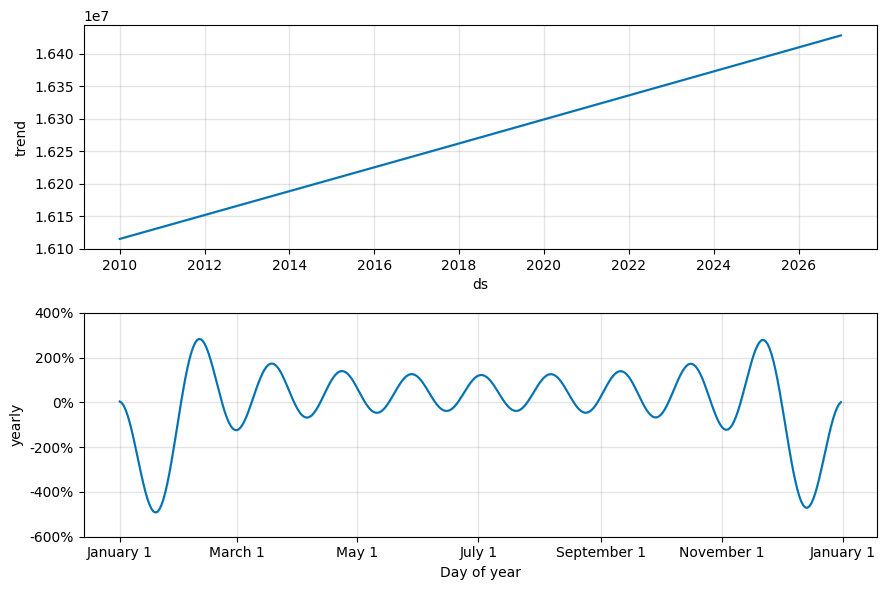

In [60]:
# CELL 33: Train Prophet & Forecast Next 3 Years
model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,   # monthly data, no weekly
    daily_seasonality=False,
    seasonality_mode='multiplicative'
)

model_prophet.fit(df_prophet)

# Make future dataframe: next 36 months (3 years)
future = model_prophet.make_future_dataframe(periods=36, freq='MS')  # MS = month start

# Predict
forecast = model_prophet.predict(future)

# Show forecast for 2025–2027
future_years = forecast[forecast['ds'].dt.year >= 2025]
print("Forecasted Sales Volume 2025–2027 (monthly):")
display(future_years[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(36))

# Plot the forecast
fig = model_prophet.plot(forecast)
plt.title("BMW Sales Volume Forecast 2010–2027 (with Uncertainty)")
plt.show()

fig_components = model_prophet.plot_components(forecast)
plt.show()

KMeans Clustering on Models & Regions

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 11.


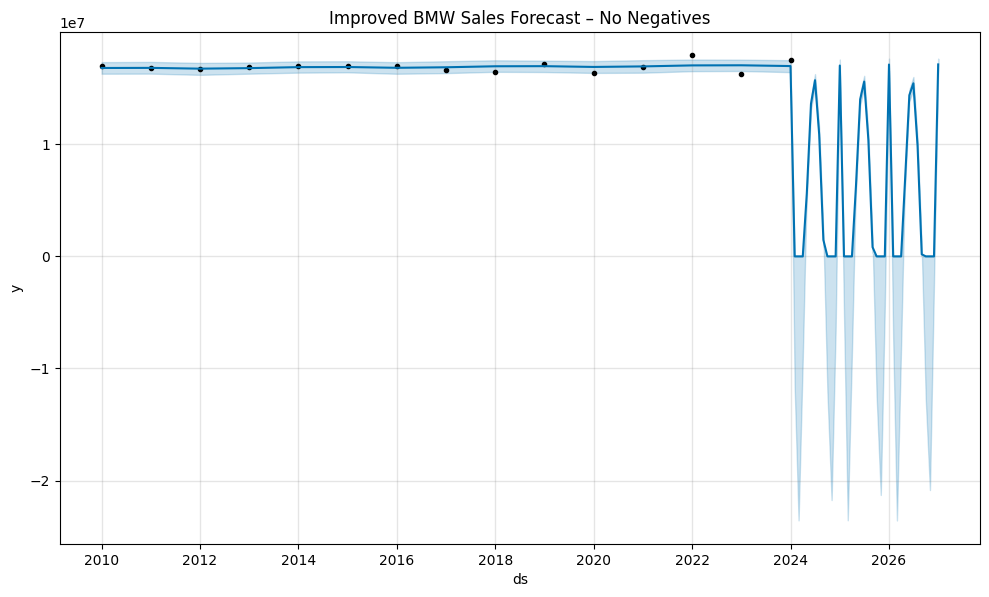

Improved Forecast 2025–2027:


,ds,yhat,yhat_lower,yhat_upper
26,2025-01-01,1.701927e+07,1.649731e+07,1.755401e+07
27,2025-02-01,0.000000e+00,0.000000e+00,-5.081036e+06
28,2025-03-01,0.000000e+00,0.000000e+00,-2.353862e+07
29,2025-04-01,0.000000e+00,0.000000e+00,-8.603312e+06
30,2025-05-01,6.308011e+06,5.778924e+06,6.824587e+06
31,2025-06-01,1.399980e+07,1.345891e+07,1.451573e+07
32,2025-07-01,1.558486e+07,1.507294e+07,1.610186e+07
33,2025-08-01,1.037698e+07,9.863711e+06,1.090173e+07
34,2025-09-01,8.192071e+05,3.263081e+05,1.361094e+06
35,2025-10-01,0.000000e+00,0.000000e+00,-1.241048e+07


In [61]:
# CELL 34: Better Prophet – Additive + floor at 0
model_prophet_better = Prophet(
    yearly_seasonality=True,
    seasonality_mode='additive',  # try additive instead of multiplicative
    changepoint_prior_scale=0.05  # less flexible changepoints
)

model_prophet_better.fit(df_prophet)

future_better = model_prophet_better.make_future_dataframe(periods=36, freq='MS')
forecast_better = model_prophet_better.predict(future_better)

# Force no negatives
forecast_better['yhat'] = forecast_better['yhat'].clip(lower=0)
forecast_better['yhat_lower'] = forecast_better['yhat_lower'].clip(lower=0)

# Plot improved
fig_better = model_prophet_better.plot(forecast_better)
plt.title("Improved BMW Sales Forecast – No Negatives")
plt.show()

# Show 2025–2027
future_years_better = forecast_better[forecast_better['ds'].dt.year >= 2025]
print("Improved Forecast 2025–2027:")
display(future_years_better[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(36))

monthly avg_price and region share

In [62]:
# CELL 35: Add regressors – monthly avg_price and region share
import pandas as pd

# Create monthly data with regressors
df_monthly = df_bmw.copy()
df_monthly['YearMonth'] = pd.to_datetime(df_monthly['Year'].astype(str) + '-01-01')

monthly_agg = df_monthly.groupby('YearMonth').agg({
    'Sales_Volume': 'sum',
    'Price_USD': 'mean',  # avg price per month
    'Region': lambda x: (x == 'North America').mean() * 100   # % from North America as example
}).reset_index()

monthly_agg = monthly_agg.rename(columns={
    'Sales_Volume': 'y',
    'Price_USD': 'avg_price',
    'Region': 'north_america_share'  # example – you can add more regions
})

monthly_agg['ds'] = monthly_agg['YearMonth']
monthly_agg = monthly_agg[['ds', 'y', 'avg_price', 'north_america_share']]

print("Monthly data with regressors ready:")
display(monthly_agg.tail(12))  # check last year

Monthly data with regressors ready:


,ds,y,avg_price,north_america_share
3,2013-01-01,16866733,74535.908298,16.776909
4,2014-01-01,16958960,74556.535224,16.537313
5,2015-01-01,17010207,74049.552710,17.450864
6,2016-01-01,16957550,75543.540862,16.612184
7,2017-01-01,16620811,75173.147416,16.018237
8,2018-01-01,16412273,75455.480781,16.351434
9,2019-01-01,17191956,75194.426002,17.836085
10,2020-01-01,16310843,75057.667083,16.380655
11,2021-01-01,16884666,75399.277580,16.221827
12,2022-01-01,17920946,74967.875503,16.388729


Prophet with regressors (avg_price + region share)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 11.


Forecast with Regressors (2025–2027 monthly):


,ds,yhat,yhat_lower,yhat_upper,avg_price,north_america_share
26,2025-01-01,1.708444e+07,1.657401e+07,1.756155e+07,2915.180398,5372.134449
27,2025-02-01,0.000000e+00,0.000000e+00,-4.947037e+06,2915.180398,5372.134449
28,2025-03-01,0.000000e+00,0.000000e+00,-1.225627e+07,2915.180398,5372.134449
29,2025-04-01,0.000000e+00,0.000000e+00,-3.778149e+06,2915.180398,5372.134449
30,2025-05-01,3.807302e+06,3.306857e+06,4.313281e+06,2915.180398,5372.134449
31,2025-06-01,7.542975e+06,7.053709e+06,8.063024e+06,2915.180398,5372.134449
32,2025-07-01,7.926349e+06,7.408394e+06,8.426811e+06,2915.180398,5372.134449
33,2025-08-01,4.932548e+06,4.406825e+06,5.462127e+06,2915.180398,5372.134449
34,2025-09-01,0.000000e+00,0.000000e+00,3.769808e+05,2915.180398,5372.134449
35,2025-10-01,0.000000e+00,0.000000e+00,-6.488947e+06,2915.180398,5372.134449


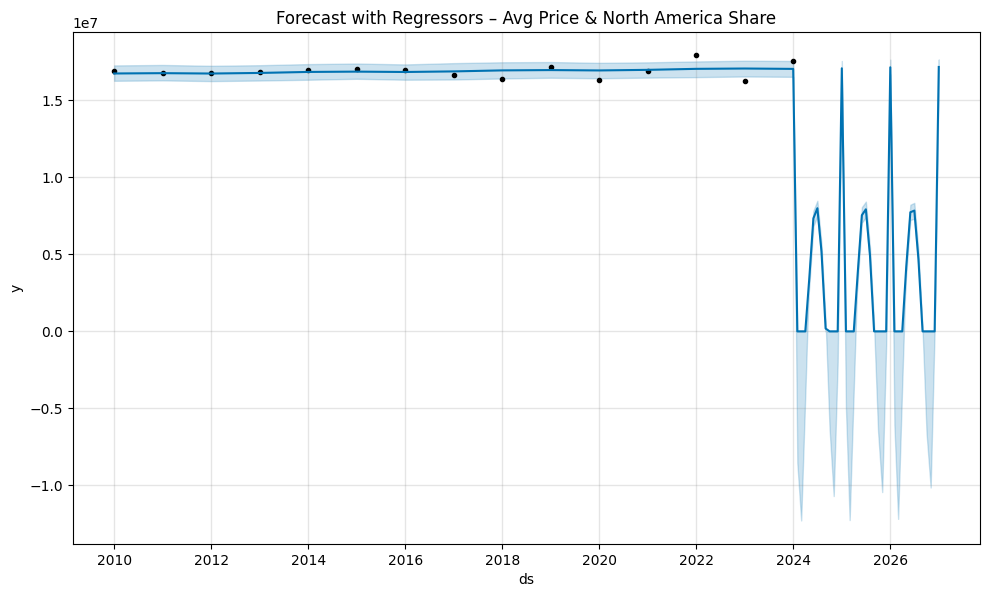

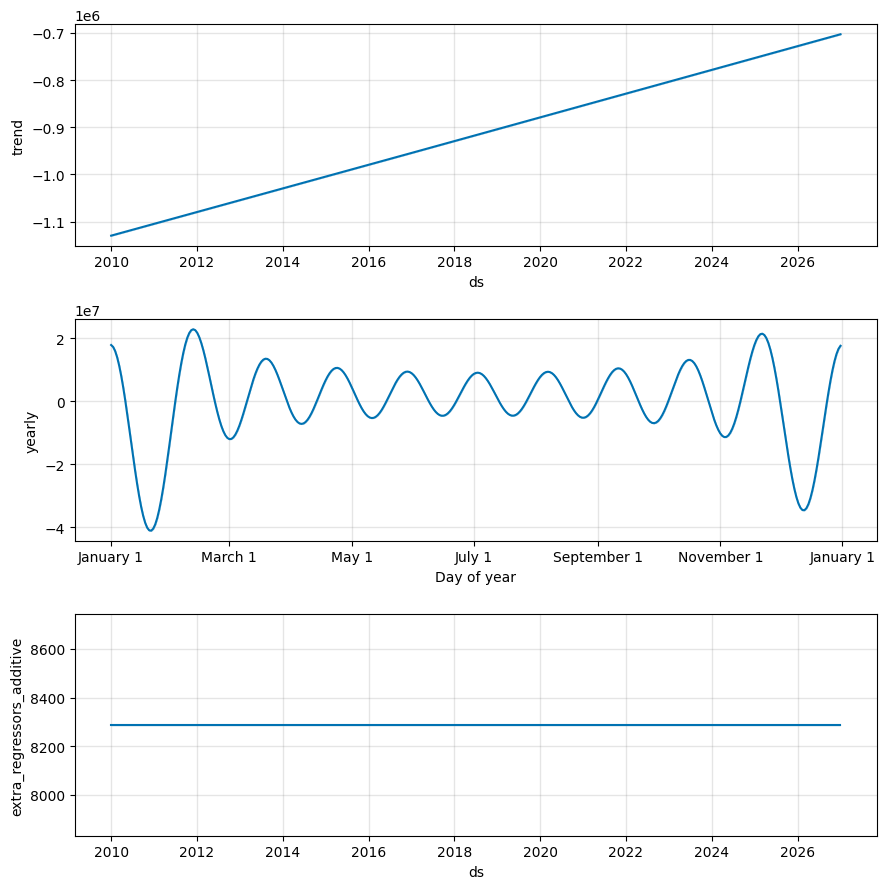

In [63]:
# CELL 36: Prophet with regressors (avg_price + region share)
from prophet import Prophet

# Prepare data
df_prophet_reg = monthly_agg[['ds', 'y', 'avg_price', 'north_america_share']].copy()

model_reg = Prophet(
    yearly_seasonality=True,
    seasonality_mode='additive',
    changepoint_prior_scale=0.05
)

# Add regressors
model_reg.add_regressor('avg_price')
model_reg.add_regressor('north_america_share')

model_reg.fit(df_prophet_reg)

# Future dataframe with FUTURE regressor values
# (for future, we need to assume values – here: keep last known avg_price, assume stable NA share)
last_avg_price = df_prophet_reg['avg_price'].iloc[-1]
last_na_share = df_prophet_reg['north_america_share'].iloc[-1]

future_reg = model_reg.make_future_dataframe(periods=36, freq='MS')

# Fill future regressors with last known values (simple assumption – improve later)
future_reg['avg_price'] = last_avg_price
future_reg['north_america_share'] = last_na_share

# Predict
forecast_reg = model_reg.predict(future_reg)

# Clip negatives
forecast_reg['yhat'] = forecast_reg['yhat'].clip(lower=0)
forecast_reg['yhat_lower'] = forecast_reg['yhat_lower'].clip(lower=0)

# Show 2025–2027
future_years_reg = forecast_reg[forecast_reg['ds'].dt.year >= 2025]
print("Forecast with Regressors (2025–2027 monthly):")
display(future_years_reg[['ds', 'yhat', 'yhat_lower', 'yhat_upper', 'avg_price', 'north_america_share']].tail(36))

# Plot
fig_reg = model_reg.plot(forecast_reg)
plt.title("Forecast with Regressors – Avg Price & North America Share")
plt.show()

fig_components_reg = model_reg.plot_components(forecast_reg)
plt.show()

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 11.


Forecast with Scaled Regressors + 3% Price Growth (Fixed):


,ds,yhat,yhat_lower,yhat_upper,avg_price,north_america_share
26,2025-01-01,1.642926e+07,1.593655e+07,1.693005e+07,77281.319021,16.924424
27,2025-02-01,0.000000e+00,0.000000e+00,-5.658259e+06,77475.442341,16.924424
28,2025-03-01,0.000000e+00,0.000000e+00,-1.303424e+07,77651.198619,16.924424
29,2025-04-01,0.000000e+00,0.000000e+00,-4.599109e+06,77846.251041,16.924424
30,2025-05-01,2.933058e+06,2.405574e+06,3.433044e+06,78035.477938,16.924424
31,2025-06-01,6.611791e+06,6.093774e+06,7.105339e+06,78231.495634,16.924424
32,2025-07-01,6.939925e+06,6.410548e+06,7.419552e+06,78421.658974,16.924424
33,2025-08-01,3.888903e+06,3.402215e+06,4.368708e+06,78618.646720,16.924424
34,2025-09-01,0.000000e+00,0.000000e+00,-7.357907e+05,78816.129280,16.924424
35,2025-10-01,0.000000e+00,0.000000e+00,-7.629416e+06,79007.713734,16.924424


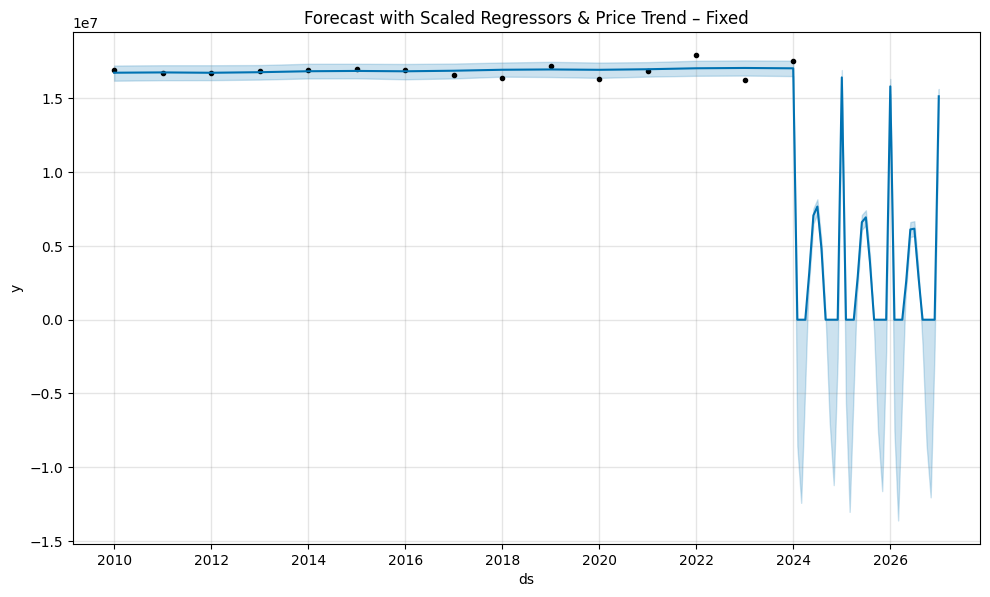

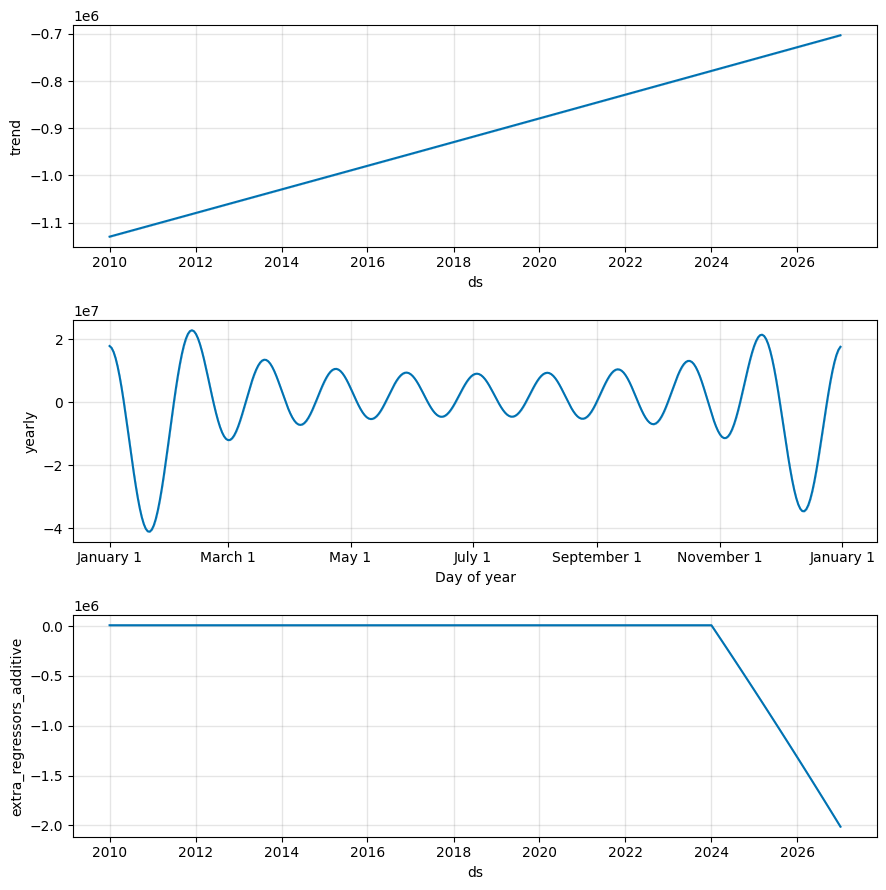

In [64]:
# CELL 37 FINAL FIXED: Prophet with Scaled Regressors + Display Fix
from sklearn.preprocessing import StandardScaler
from prophet import Prophet
import pandas as pd

# 1. Scale historical
scaler_price = StandardScaler()
scaler_na = StandardScaler()

df_prophet_reg['avg_price_scaled'] = scaler_price.fit_transform(df_prophet_reg[['avg_price']])
df_prophet_reg['na_share_scaled'] = scaler_na.fit_transform(df_prophet_reg[['north_america_share']])

# 2. Fresh model + add regressors BEFORE fit
model_reg = Prophet(
    yearly_seasonality=True,
    seasonality_mode='additive',
    changepoint_prior_scale=0.05
)

model_reg.add_regressor('avg_price_scaled')
model_reg.add_regressor('na_share_scaled')

# 3. Fit
model_reg.fit(df_prophet_reg[['ds', 'y', 'avg_price_scaled', 'na_share_scaled']])

# 4. Future dataframe (only ds + periods)
future_reg = model_reg.make_future_dataframe(periods=36, freq='MS')

# 5. Prepare regressors for future (Prophet will use these during prediction)
# Create a separate df for regressors to merge back later
regressors_future = pd.DataFrame(index=future_reg.index)
regressors_future['ds'] = future_reg['ds']

# Fill last known values + trend for avg_price
last_price = df_prophet_reg['avg_price'].iloc[-1]
last_na_share = df_prophet_reg['north_america_share'].iloc[-1]

regressors_future['avg_price'] = last_price
regressors_future['north_america_share'] = last_na_share

# Apply 3% yearly growth to avg_price in future
for i, row in regressors_future.iterrows():
    if row['ds'] > df_prophet_reg['ds'].max():
        years_ahead = (row['ds'] - df_prophet_reg['ds'].max()).days / 365.25
        regressors_future.at[i, 'avg_price'] = last_price * (1.03 ** years_ahead)

# Scale them
regressors_future['avg_price_scaled'] = scaler_price.transform(regressors_future[['avg_price']])
regressors_future['na_share_scaled'] = scaler_na.transform(regressors_future[['north_america_share']])

# 6. Predict (Prophet uses the scaled columns)
forecast_reg = model_reg.predict(regressors_future[['ds', 'avg_price_scaled', 'na_share_scaled']])

# Clip negatives
forecast_reg['yhat'] = forecast_reg['yhat'].clip(lower=0)
forecast_reg['yhat_lower'] = forecast_reg['yhat_lower'].clip(lower=0)

# 7. Merge regressors back for display
forecast_reg = forecast_reg.merge(regressors_future[['ds', 'avg_price', 'north_america_share']], on='ds', how='left')

# 8. Show 2025–2027
future_years_reg = forecast_reg[forecast_reg['ds'].dt.year >= 2025]
print("Forecast with Scaled Regressors + 3% Price Growth (Fixed):")
display(future_years_reg[['ds', 'yhat', 'yhat_lower', 'yhat_upper', 'avg_price', 'north_america_share']].tail(36))

# Plots
fig_reg = model_reg.plot(forecast_reg)
plt.title("Forecast with Scaled Regressors & Price Trend – Fixed")
plt.show()

fig_components = model_reg.plot_components(forecast_reg)
plt.show()

KMeans Clustering – Find High-Value BMW Segments

In [65]:
# CELL 38: KMeans Clustering – Find High-Value BMW Segments
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd
import plotly.express as px

# Step 1: Aggregate by Model + Region + Fuel_Type
cluster_df = df_bmw.groupby(['Model', 'Region', 'Fuel_Type']).agg({
    'Price_USD': ['mean', 'sum'],          # Avg price & total revenue
    'Sales_Volume': 'sum',                 # Total units sold
    'Mileage_KM': 'mean',                  # Avg mileage
    'Engine_Size_L': 'mean'                # Avg engine size
}).reset_index()

# Flatten multi-index columns
cluster_df.columns = [
    'Model', 'Region', 'Fuel_Type',
    'Avg_Price', 'Total_Revenue',
    'Total_Sales_Volume', 'Avg_Mileage', 'Avg_Engine'
]

# Step 2: Select features for clustering
features = ['Avg_Price', 'Total_Revenue', 'Total_Sales_Volume', 'Avg_Mileage', 'Avg_Engine']
X_cluster = cluster_df[features]

# Scale (very important for KMeans)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Step 3: Run KMeans (try 4 clusters – you can change to 3–6)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_df['Cluster'] = kmeans.fit_predict(X_scaled)

# Step 4: Quick summary of clusters
print("Cluster Summary (sorted by Total_Revenue descending):")
cluster_summary = cluster_df.groupby('Cluster').agg({
    'Total_Revenue': 'sum',
    'Total_Sales_Volume': 'sum',
    'Avg_Price': 'mean',
    'Avg_Mileage': 'mean',
    'Avg_Engine': 'mean',
    'Model': 'count'  # number of combos in cluster
}).round(2).sort_values('Total_Revenue', ascending=False)

display(cluster_summary)

# Step 5: Show top 10 combos per cluster (high-value focus)
print("\nTop 10 combos per cluster (by Total_Revenue):")
for c in sorted(cluster_df['Cluster'].unique()):
    print(f"\nCluster {c}:")
    display(cluster_df[cluster_df['Cluster'] == c]
            .sort_values('Total_Revenue', ascending=False)
            .head(10)[['Model', 'Region', 'Fuel_Type', 'Avg_Price', 'Total_Revenue', 'Total_Sales_Volume', 'Avg_Mileage']])

# Step 6: Interactive scatter plot (hover to see details)
fig = px.scatter(cluster_df,
                 x='Avg_Mileage',
                 y='Avg_Price',
                 size='Total_Revenue',
                 color='Cluster',
                 hover_data=['Model', 'Region', 'Fuel_Type', 'Total_Sales_Volume', 'Avg_Engine'],
                 title="BMW Clusters: Avg Mileage vs Avg Price (size = Revenue)",
                 size_max=60)
fig.show()

Cluster Summary (sorted by Total_Revenue descending):


,Total_Revenue,Total_Sales_Volume,Avg_Price,Avg_Mileage,Avg_Engine,Model
Cluster,,,,,,
0,1062943428,73559154,74338.74,98926.56,3.25,70
2,997053887,65294930,76451.67,101928.47,3.31,69
3,884870561,59520053,75564.91,100749.40,3.16,63
1,806862169,55001597,73726.90,99697.59,3.26,62



Top 10 combos per cluster (by Total_Revenue):

Cluster 0:


,Model,Region,Fuel_Type,Avg_Price,Total_Revenue,Total_Sales_Volume,Avg_Mileage
78,M3,Asia,Hybrid,78121.433180,16952351,1126927,104712.410138
251,i8,Europe,Petrol,77237.465753,16915005,1154451,98044.858447
6,3 Series,Asia,Hybrid,76559.922727,16843183,1130637,97845.304545
250,i8,Europe,Hybrid,76587.235023,16619430,1124938,108618.737327
62,7 Series,Middle East,Hybrid,75384.431818,16584575,1101791,99849.836364
161,X3,North America,Electric,75831.380734,16531241,1131485,98027.321101
66,7 Series,North America,Hybrid,76571.023256,16462770,1150030,109504.460465
126,X1,Asia,Hybrid,74835.251142,16388920,1114204,95596.735160
246,i8,Asia,Hybrid,75891.485981,16240778,1021660,103639.920561
27,5 Series,Africa,Petrol,75235.443925,16100385,1071653,89846.462617



Cluster 1:


,Model,Region,Fuel_Type,Avg_Price,Total_Revenue,Total_Sales_Volume,Avg_Mileage
241,i8,Africa,Electric,73365.586735,14379655,844341,93875.923469
234,i3,North America,Hybrid,72917.365979,14145969,938994,94722.618557
34,5 Series,Europe,Hybrid,74740.578378,13827007,875738,97485.632432
9,3 Series,Europe,Electric,72860.878307,13770706,983720,95386.624339
108,M5,Middle East,Diesel,72094.890052,13770124,985057,100537.413613
175,X5,Asia,Petrol,73487.219251,13742110,914769,100296.032086
195,X6,Africa,Petrol,72619.698413,13725123,941362,98544.603175
174,X5,Asia,Hybrid,73272.919786,13702036,937851,100865.016043
15,3 Series,Middle East,Petrol,75446.756906,13655863,886009,94348.381215
114,M5,North America,Hybrid,73511.940541,13599709,927834,95498.497297



Cluster 2:


,Model,Region,Fuel_Type,Avg_Price,Total_Revenue,Total_Sales_Volume,Avg_Mileage
51,7 Series,Africa,Petrol,79311.752475,16020974,992014,105818.004950
153,X3,Europe,Electric,77560.099502,15589580,993559,99732.298507
25,5 Series,Africa,Electric,78219.252525,15487412,1016635,108764.212121
260,i8,South America,Diesel,77236.690000,15447338,984759,93855.280000
107,M5,Europe,Petrol,75954.336634,15342776,1016044,105912.509901
64,7 Series,North America,Diesel,77547.208122,15276800,1029797,97548.868020
58,7 Series,Europe,Hybrid,75205.517241,15266720,999471,104761.019704
8,3 Series,Europe,Diesel,80988.191489,15225780,909993,102957.611702
61,7 Series,Middle East,Electric,78775.512953,15203674,942259,99393.834197
233,i3,North America,Electric,77349.989796,15160598,943751,98605.581633



Cluster 3:


,Model,Region,Fuel_Type,Avg_Price,Total_Revenue,Total_Sales_Volume,Avg_Mileage
20,3 Series,South America,Diesel,76553.797980,15157652,976434,95799.626263
120,X1,Africa,Diesel,77889.530928,15110569,1001287,96460.855670
80,M3,Europe,Diesel,74886.223881,15052131,931394,104853.258706
65,7 Series,North America,Electric,76730.856410,14962517,1013023,100095.482051
186,X5,North America,Hybrid,75061.101010,14862098,995033,98087.297980
133,X1,Middle East,Electric,76818.829016,14826034,985230,100779.445596
235,i3,North America,Petrol,75612.326531,14820016,983842,95784.362245
71,7 Series,South America,Petrol,74927.385787,14760695,975135,98279.609137
263,i8,South America,Petrol,74538.631313,14758649,937240,101770.666667
109,M5,Middle East,Electric,77938.201058,14730320,941976,99674.894180
